In [25]:
!pip install langchain-community langchain-openai langgraph pydantic python-dotenv semantic-chunkers semantic-router tavily-python


DEPRECATION: Loading egg at c:\users\anant\appdata\local\programs\python\python312\lib\site-packages\vboxapi-1.0-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import os
import operator
import uuid
from typing import Annotated, Dict, List, Optional, Tuple, TypedDict

from IPython.display import Image, display
from langchain_community.utils.math import cosine_similarity
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from semantic_chunkers import StatisticalChunker
from semantic_router.encoders import OpenAIEncoder


In [27]:
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

tavily_search = TavilySearchResults(max_results=3)
llm = ChatOpenAI(model="gpt-4o", temperature=0)
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")


C:\Users\anant\AppData\Local\Temp\ipykernel_18020\3481529501.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=3)


In [28]:
class Goals(BaseModel):
    """Structure for defining learning goals"""
    goals: str = Field(None, description="Learning goals")

class LearningCheckpoint(BaseModel):
    """Structure for a single checkpoint"""
    description: str = Field(..., description="Main checkpoint description")
    criteria: List[str] = Field(..., description="List of success criteria")
    verification: str = Field(..., description="How to verify this checkpoint")

class Checkpoints(BaseModel):
    """Main checkpoints container with index tracking"""
    checkpoints: List[LearningCheckpoint] = Field(
        ...,
        description="List of checkpoints covering foundation, application, and mastery levels"
    )

class SearchQuery(BaseModel):
    """Structure for search query collection"""
    search_queries: List[str] = Field(None, description="Search queries for retrieval.")

class LearningVerification(BaseModel):
    """Structure for verification results"""
    understanding_level: float = Field(..., ge=0, le=1)
    feedback: str
    suggestions: List[str]
    context_alignment: bool

class FeynmanTeaching(BaseModel):
    """Structure for Feynman teaching method"""
    simplified_explanation: str
    key_concepts: List[str]
    analogies: List[str]

class QuestionOutput(BaseModel):
    """Structure for question generation output"""
    question: str

class InContext(BaseModel):
    """Structure for context verification"""
    is_in_context: str = Field(..., description="Yes or No")


In [29]:
class LearningtState(TypedDict):
    topic: str
    goals: List[Goals]
    context: str
    context_chunks: Annotated[list, operator.add]
    context_key: str
    search_queries: SearchQuery
    checkpoints: Checkpoints
    verifications: LearningVerification
    teachings: FeynmanTeaching
    current_checkpoint: int
    current_question: QuestionOutput
    current_answer: str


In [30]:
def extract_content_from_chunks(chunks):
    """Extract and combine content from chunks with splits attribute."""
    content = []
    for chunk in chunks:
        if hasattr(chunk, 'splits') and chunk.splits:
            chunk_content = ' '.join(chunk.splits)
            content.append(chunk_content)
    return '\n'.join(content)

def format_checkpoints_as_message(checkpoints: Checkpoints) -> str:
    """Convert Checkpoints object to a formatted string for the message."""
    message = "Here are the learning checkpoints:\n\n"
    for i, checkpoint in enumerate(checkpoints.checkpoints, 1):
        message += f"Checkpoint {i}:\n"
        message += f"Description: {checkpoint.description}\n"
        message += "Success Criteria:\n"
        for criterion in checkpoint.criteria:
            message += f"- {criterion}\n"
    return message

def generate_checkpoint_message(checks: List[LearningCheckpoint]) -> HumanMessage:
    """Generate a formatted message for learning checkpoints that need context."""
    formatted_checks = []
    for check in checks:
        checkpoint_text = f"""
        Description: {check.description}
        Success Criteria:
        {chr(10).join(f'- {criterion}' for criterion in check.criteria)}
        Verification Method: {check.verification}
        """
        formatted_checks.append(checkpoint_text)
    all_checks = "\n---\n".join(formatted_checks)
    checkpoints_message = HumanMessage(content=f"""The following learning checkpoints need additional context:
        {all_checks}

        Please generate search queries to find relevant information.""")
    return checkpoints_message


In [31]:
learning_checkpoints_generator = SystemMessage(content="""You will be given a learning topic title and learning objectives.
Your goal is to generate clear learning checkpoints that will help verify understanding and progress through the topic.
The output should be in the following dictionary structure:
checkpoint 
-> description (level checkpoint description)
-> criteria
-> verification (How to verify this checkpoint (Feynman Methods))
Requirements for each checkpoint:
- Description should be clear and concise
- Criteria should be specific and measurable (3-5 items)
- Verification method should be practical and appropriate for the level
- Verification will be checked by language model, so it must by in natural language
- All elements should align with the learning objectives
- Use action verbs and clear language
Ensure all checkpoints progress logically from foundation to mastery.
IMPORTANT - ANSWER ONLY 3 CHECKPOINTS""")

checkpoint_based_query_generator = SystemMessage(content="""You will be given learning checkpoints for a topic.
Your goal is to generate search queries that will retrieve content matching each checkpoint's requirements from retrieval systems or web search.
Follow these steps:
1. Analyze each learning checkpoint carefully
2. For each checkpoint, generate ONE targeted search query that will retrieve:
   - Content for checkpoint verification""")

validate_context = SystemMessage(content="""You will be given a learning criteria and context.
Check if the the criteria could be answered using the context.
Always answer YES or NO""")

question_generator = SystemMessage(content="""You will be given a checkpoint description, success criteria, and verification method.
Your goal is to generate an appropriate question that aligns with the checkpoint's verification requirements.
The question should:
1. Follow the specified verification method
2. Cover all success criteria
3. Encourage demonstration of understanding
4. Be clear and specific
Output should be a single, well-formulated question that effectively tests the checkpoint's learning objectives.""")

answer_verifier = SystemMessage(content="""You will be given a student's answer, question, checkpoint details, and relevant context.
Your goal is to analyze the answer against the checkpoint criteria and provided context.
Analyze considering:
1. Alignment with verification method specified
2. Coverage of all success criteria
3. Use of relevant concepts from context
4. Depth and accuracy of understanding
Output should include:
- understanding_level: float between 0 and 1
- feedback: detailed explanation of the assessment
- suggestions: list of specific improvements
- context_alignment: boolean indicating if the answer aligns with provided context""")

feynman_teacher = SystemMessage(content="""You will be given verification results, checkpoint criteria, and learning context.
Your goal is to create a Feynman-style teaching explanation for concepts that need reinforcement.
The explanation should include:
1. Simplified explanation without technical jargon
2. Concrete, relatable analogies
3. Key concepts to remember
Output should follow the Feynman technique:
- simplified_explanation: clear, jargon-free explanation
- key_concepts: list of essential points
- analogies: list of relevant, concrete comparisons
Focus on making complex ideas accessible and memorable.""")


In [32]:
class ContextStore:
    """Store for managing context chunks and their embeddings in memory."""
    def __init__(self):
        self.store = InMemoryStore()
        
    def save_context(self, context_chunks: list, embeddings: list, key: str = None):
        namespace = ("context",)
        if key is None:
            key = str(uuid.uuid4())
        value = {
            "chunks": context_chunks,
            "embeddings": embeddings
        }
        self.store.put(namespace, key, value)
        return key
        
    def get_context(self, context_key: str):
        namespace = ("context",)
        memory = self.store.get(namespace, context_key)
        return memory.value

context_store = ContextStore()


In [33]:
def generate_query(state: LearningtState):
    structured_llm = llm.with_structured_output(SearchQuery)
    checkpoints_message = HumanMessage(content=format_checkpoints_as_message(state['checkpoints']))
    messages = [checkpoint_based_query_generator, checkpoints_message]
    search_queries = structured_llm.invoke(messages)
    return {"search_queries": search_queries}

def search_web(state: LearningtState):
    search_queries = state["search_queries"].search_queries
    all_search_docs = []
    for query in search_queries:
        search_docs = tavily_search.invoke(query)
        all_search_docs.extend(search_docs)

    formatted_search_docs = [
        f'Context: {doc["content"]}\n Source: {doc["url"]}\n'
        for doc in all_search_docs
    ]

    chunk_embeddings = embeddings.embed_documents(formatted_search_docs)
    context_key = context_store.save_context(
        formatted_search_docs,
        chunk_embeddings,
        key=state.get('context_key')
    )

    return {"context_chunks": formatted_search_docs, "context_key": context_key}

def generate_checkpoints(state: LearningtState):
    structured_llm = llm.with_structured_output(Checkpoints)
    messages = [
        learning_checkpoints_generator,
        SystemMessage(content=f"Topic: {state['topic']}"),
        SystemMessage(content=f"Goals: {', '.join(str(goal) for goal in state['goals'])}")
    ]
    checkpoints = structured_llm.invoke(messages)
    return {"checkpoints": checkpoints}

def chunk_context(state: LearningtState):
    encoder = OpenAIEncoder(name="text-embedding-3-large")
    chunker = StatisticalChunker(
        encoder=encoder,
        min_split_tokens=128,
        max_split_tokens=512
    )

    chunks = chunker([state['context']])
    content = []
    for chunk in chunks:
        content.append(extract_content_from_chunks(chunk))

    chunk_embeddings = embeddings.embed_documents(content)
    context_key = context_store.save_context(
        content,
        chunk_embeddings,
        key=state.get('context_key')
    )
    return {"context_chunks": content, "context_key": context_key}

def context_validation(state: LearningtState):
    context = context_store.get_context(state['context_key'])
    chunks = context['chunks']
    chunk_embeddings = context['embeddings']

    checks = []
    structured_llm = llm.with_structured_output(InContext)

    for checkpoint in state['checkpoints'].checkpoints:
        query = embeddings.embed_query(checkpoint.verification)
        similarities = cosine_similarity([query], chunk_embeddings)[0]
        top_3_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)[:3]
        relevant_chunks = [chunks[i] for i in top_3_indices]

        messages = [
            validate_context,
            HumanMessage(content=f"""
            Criteria:
            {chr(10).join(f"- {c}" for c in checkpoint.criteria)}

            Context:
            {chr(10).join(relevant_chunks)}
            """)
        ]

        response = structured_llm.invoke(messages)
        if response.is_in_context.lower() == "no":
            checks.append(checkpoint)

    if checks:
        structured_llm = llm.with_structured_output(SearchQuery)
        checkpoints_message = generate_checkpoint_message(checks)

        messages = [checkpoint_based_query_generator, checkpoints_message]
        search_queries = structured_llm.invoke(messages)
        return {"search_queries": search_queries}

    return {"search_queries": None}

def generate_question(state: LearningtState):
    structured_llm = llm.with_structured_output(QuestionOutput)
    current_checkpoint = state['current_checkpoint']
    checkpoint_info = state['checkpoints'].checkpoints[current_checkpoint]

    messages = [
        question_generator,
        HumanMessage(content=f"""
        Checkpoint Description: {checkpoint_info.description}
        Success Criteria:
        {chr(10).join(f"- {c}" for c in checkpoint_info.criteria)}
        Verification Method: {checkpoint_info.verification}

        Generate an appropriate verification question.""")
    ]

    question_output = structured_llm.invoke(messages)
    return {"current_question": question_output.question}

def verify_answer(state: LearningtState):
    structured_llm = llm.with_structured_output(LearningVerification)
    current_checkpoint = state['current_checkpoint']
    checkpoint_info = state['checkpoints'].checkpoints[current_checkpoint]

    context = context_store.get_context(state['context_key'])
    chunks = context['chunks']
    chunk_embeddings = context['embeddings']

    query = embeddings.embed_query(checkpoint_info.verification)

    similarities = cosine_similarity([query], chunk_embeddings)[0]
    top_3_indices = sorted(range(len(similarities)), key=lambda i: similarities[i], reverse=True)[:3]
    relevant_chunks = [chunks[i] for i in top_3_indices]

    messages = [
        answer_verifier,
        HumanMessage(content=f"""
        Question: {state['current_question']}
        Answer: {state['current_answer']}

        Checkpoint Description: {checkpoint_info.description}
        Success Criteria:
        {chr(10).join(f"- {c}" for c in checkpoint_info.criteria)}
        Verification Method: {checkpoint_info.verification}

        Context:
        {chr(10).join(relevant_chunks)}

        Assess the answer.""")
    ]

    verification = structured_llm.invoke(messages)
    return {"verifications": verification}

def teach_concept(state: LearningtState):
    structured_llm = llm.with_structured_output(FeynmanTeaching)
    current_checkpoint = state['current_checkpoint']
    checkpoint_info = state['checkpoints'].checkpoints[current_checkpoint]

    messages = [
        feynman_teacher,
        HumanMessage(content=f"""
        Criteria: {checkpoint_info.criteria}
        Verification: {state['verifications']}

        Context:
        {state['context_chunks']}

        Create a Feynman teaching explanation.""")
    ]

    teaching = structured_llm.invoke(messages)
    return {"teachings": teaching}


In [34]:
def user_answer(state: LearningtState):
    """Placeholder for handling user's answer input."""
    pass

def next_checkpoint(state: LearningtState):
    """Advances to the next checkpoint in the learning sequence."""
    current_checkpoint = state['current_checkpoint'] + 1
    return {'current_checkpoint': current_checkpoint}


In [35]:
def route_context(state: LearningtState):
    """Determines whether to process existing context or generate new search queries."""
    if state.get("context"):
        return 'chunk_context'
    return 'generate_query'

def route_verification(state: LearningtState):
    """Determines next step based on verification results and checkpoint progress."""
    current_checkpoint = state['current_checkpoint']
    if state['verifications'].understanding_level < 0.7:
        return 'teach_concept'
    if current_checkpoint + 1 < len(state['checkpoints'].checkpoints):
        return 'next_checkpoint'
    return END

def route_teaching(state: LearningtState):
    """Routes to next checkpoint or ends session after teaching intervention."""
    current_checkpoint = state['current_checkpoint']
    if current_checkpoint + 1 < len(state['checkpoints'].checkpoints):
        return 'next_checkpoint'
    return END

def route_search(state: LearningtState):
    """Directs flow between question generation and web search based on query status."""
    if state['search_queries'] is None:
        return "generate_question"
    return "search_web"


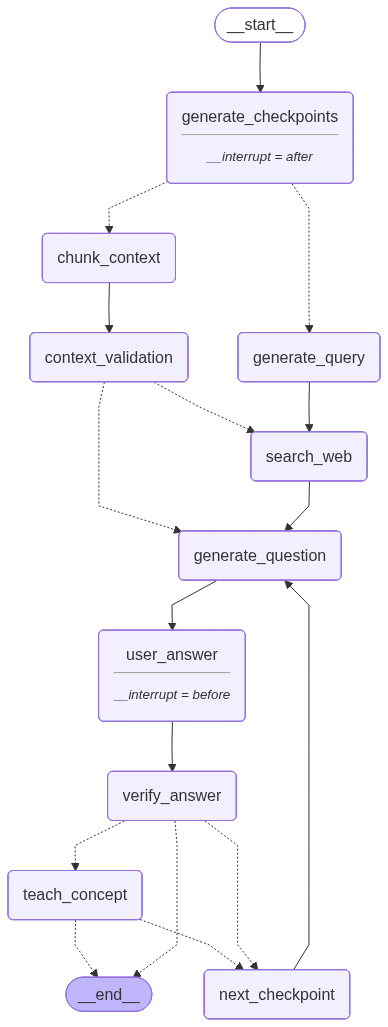

In [36]:
searcher = StateGraph(LearningtState)
memory = MemorySaver()
context_store = ContextStore()

searcher.add_node("generate_query", generate_query)
searcher.add_node("search_web", search_web)
searcher.add_node("chunk_context", chunk_context)
searcher.add_node("context_validation", context_validation)
searcher.add_node("generate_checkpoints", generate_checkpoints)
searcher.add_node("generate_question", generate_question)
searcher.add_node("next_checkpoint", next_checkpoint)
searcher.add_node("user_answer", user_answer)
searcher.add_node("verify_answer", verify_answer)
searcher.add_node("teach_concept", teach_concept)

searcher.add_edge(START, "generate_checkpoints")
searcher.add_conditional_edges('generate_checkpoints', route_context, ['chunk_context', 'generate_query'])
searcher.add_edge("generate_query", "search_web")
searcher.add_edge("search_web", "generate_question")
searcher.add_edge("chunk_context", 'context_validation')
searcher.add_conditional_edges('context_validation', route_search, ['search_web', 'generate_question'])

searcher.add_edge("generate_question", "user_answer")
searcher.add_edge("user_answer", "verify_answer")
searcher.add_conditional_edges(
    "verify_answer",
    route_verification,
    {
        "next_checkpoint": "next_checkpoint",
        "teach_concept": "teach_concept",
        END: END
    }
)

searcher.add_conditional_edges(
    "teach_concept",
    route_teaching,
    {
        "next_checkpoint": "next_checkpoint",
        END: END
    }
)
searcher.add_edge("next_checkpoint", "generate_question")

graph = searcher.compile(
    interrupt_after=["generate_checkpoints"],
    interrupt_before=["user_answer"],
    checkpointer=memory
)

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))


In [37]:
def print_checkpoints(event):
    checkpoints = event.get('checkpoints', '')
    if checkpoints:
        for i, checkpoint in enumerate(checkpoints.checkpoints, 1):
            print(f"Checkpoint {i}:")
            print("Description:", checkpoint.description)
            print("Criteria:", checkpoint.criteria)
            print("Verification:", checkpoint.verification)
            print()

def print_verification_results(event):
    verifications = event.get('verifications', '')
    if verifications:
        print("Understanding:", verifications.understanding_level)
        print("Feedback:", verifications.feedback)
        print("Suggestions:", verifications.suggestions)
        print("Context alignment:", verifications.context_alignment)
        print()

def print_teaching_results(event):
    teachings = event.get('teachings', '')
    if teachings:
        print("Simplified:", teachings.simplified_explanation)
        print("Key concepts:", teachings.key_concepts)
        print("Analogies:", teachings.analogies)
        print()


In [38]:
note = """Anemia: A Comprehensive Overview
Definition
Anemia is a medical condition characterized by a decrease in the total number of red blood cells (RBCs) or hemoglobin in the blood. This reduction leads to a diminished ability to carry oxygen to the body's tissues, affecting overall body function and health.
Blood Components and Their Role
Red blood cells, also known as erythrocytes, are fundamental components of blood that carry oxygen throughout the body. These cells contain hemoglobin, an iron-containing protein that gives blood its characteristic red color and is responsible for oxygen transport. The typical lifespan of a red blood cell is approximately 120 days, after which it must be replaced by new cells produced in the bone marrow.
Types of Anemia
Iron Deficiency Anemia represents the most prevalent form of anemia worldwide. It occurs due to insufficient iron intake or absorption, particularly affecting pregnant women, growing children, menstruating women, and individuals with poor nutritional intake.
Vitamin Deficiency Anemia develops when the body lacks sufficient amounts of vitamin B12 or folate (vitamin B9). This deficiency can stem from dietary inadequacies or problems with nutrient absorption in the digestive system.
Aplastic Anemia, though rare, presents a serious condition where the bone marrow fails to produce adequate blood cells. This form can be either inherited through genetic factors or acquired through various environmental causes or medical conditions.
Hemolytic Anemia occurs when red blood cells are destroyed at a rate faster than the body can replace them. This condition may be inherited through genetic factors or acquired through various external causes.
Clinical Manifestations
Anemia manifests through various symptoms including persistent fatigue and weakness. Patients often present with pale or yellowish skin, experience shortness of breath, and may suffer from dizziness. Additional symptoms include irregular heartbeat patterns, frequent headaches, cold extremities, and occasional chest pain.
Diagnostic Approach
Diagnosis begins with a thorough physical examination by a healthcare provider. Blood tests form the cornerstone of diagnosis, including a Complete Blood Count (CBC), assessment of iron levels, vitamin B12 measurement, and folate level determination. These tests help identify the specific type of anemia and guide appropriate treatment.
Treatment Strategies
Dietary modification serves as a fundamental treatment approach. This involves increasing consumption of iron-rich foods such as red meat, dark leafy vegetables, legumes, and iron-fortified cereals.
Supplementation often proves necessary and may include iron supplements, vitamin B12, or folic acid, depending on the underlying cause of anemia.
Medical interventions become necessary in severe cases. Blood transfusions may be required for severe anemia, while bone marrow transplantation might be considered for cases of aplastic anemia.
Preventive Measures
Prevention centers on maintaining a balanced diet rich in essential nutrients, particularly iron, vitamin B12, folate, and vitamin C, which enhances iron absorption. Regular medical check-ups allow for early detection and intervention.
Certain populations require special attention regarding prevention. These include pregnant women, menstruating women, growing children, individuals following vegetarian or vegan diets, and athletes who may have increased nutritional demands.
Potential Complications
Untreated anemia can lead to several serious complications. These include severe fatigue that impacts daily activities, complications during pregnancy, cardiovascular problems, depression, and cognitive difficulties that may affect work or school performance.
Clinical Significance
Anemia often serves as an indicator of other underlying medical conditions. Therefore, early detection and appropriate treatment prove crucial for optimal outcomes. Different forms of anemia require specific treatment approaches, and regular monitoring may be necessary to ensure treatment effectiveness."""


In [39]:
initial_input = {
    "topic": "Anemia",
    "goals": ['Im medical student, i want to master the diagnosis of Anemia'],
    "context": note,
    "current_checkpoint": 0
}


In [40]:
thread = {"configurable": {"thread_id": "20"}}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    print_checkpoints(event)


Checkpoint 1:
Description: Understand the basic concepts and types of anemia.
Criteria: ['Define anemia and its general causes.', 'Identify the different types of anemia (e.g., iron deficiency, vitamin B12 deficiency, hemolytic anemia).', 'Explain the physiological impact of anemia on the body.']
Verification: Explain anemia to a peer, including its definition, types, and effects on the body, ensuring they understand the basic concepts.

Checkpoint 2:
Description: Apply diagnostic criteria to identify different types of anemia.
Criteria: ['List the common symptoms associated with anemia.', 'Describe the laboratory tests used to diagnose anemia (e.g., CBC, reticulocyte count, iron studies).', 'Differentiate between the laboratory findings of various types of anemia.']
Verification: Discuss with a peer the process of diagnosing anemia, including symptoms and lab tests, and differentiate between types based on lab results.

Checkpoint 3:
Description: Master the process of diagnosing anemi

In [41]:
from typing import List
import ipywidgets as widgets
from IPython.display import display
from pydantic import BaseModel

def create_checkpoint_editor(checkpoints_model: Checkpoints):
    """
    Creates an interactive checkpoint editor using a Pydantic model.
    
    Args:
        checkpoints_model: Pydantic model of Checkpoints class
    """
    # Convert to list of dictionaries for easier editing
    checkpoints = [cp.model_dump() for cp in checkpoints_model.checkpoints]
    checkpoints_widgets = []
    accepted_checkpoints = []
    
    def create_criterion_widget(checkpoint_index: int, criterion_value: str = "", criterion_index: int = None):
        """Creates a widget for a single criterion with a delete button"""
        criterion_container = widgets.HBox([
            widgets.Text(
                value=criterion_value,
                description=f'{criterion_index + 1}.' if criterion_index is not None else 'New',
                layout=widgets.Layout(width='85%')
            ),
            widgets.Button(
                description='Delete',
                button_style='danger',
                layout=widgets.Layout(width='15%')
            )
        ])
        
        def on_criterion_change(change):
            nonlocal criterion_index
            if criterion_index is not None:
                checkpoints[checkpoint_index]['criteria'][criterion_index] = change['new']
        
        def remove_criterion(b):
            if criterion_index is not None:
                checkpoints[checkpoint_index]['criteria'].pop(criterion_index)
                update_checkpoint_widget(checkpoint_index)
        
        criterion_container.children[0].observe(on_criterion_change, names='value')
        criterion_container.children[1].on_click(remove_criterion)
        
        return criterion_container
    
    def create_checkpoint_widget(checkpoint: dict, index: int):
        """Creates a widget for a single checkpoint"""
        
        def on_accept_change(change):
            if change['new']:
                accepted_checkpoints.append(index)
            else:
                if index in accepted_checkpoints:
                    accepted_checkpoints.remove(index)
        
        def on_description_change(change):
            checkpoints[index]['description'] = change['new']
        
        def on_verification_change(change):
            checkpoints[index]['verification'] = change['new']
        
        def add_criterion(b):
            checkpoints[index]['criteria'].append("")
            update_checkpoint_widget(index)
        
        def remove_checkpoint(b):
            checkpoints.pop(index)
            update_all_checkpoints()
        
        # Header with checkbox and delete button
        header = widgets.HBox([
            widgets.HTML(f'<h3 style="margin: 0;">Checkpoint {index + 1}</h3>'),
            widgets.Checkbox(
                value=False,
                description='Accept',
                indent=False,
                layout=widgets.Layout(margin='5px 0 0 20px')
            ),
            widgets.Button(
                description='Delete checkpoint',
                button_style='danger',
                layout=widgets.Layout(margin='0 0 0 20px')
            )
        ])
        
        # Description
        description = widgets.Textarea(
            value=checkpoint['description'],
            description='Description:',
            layout=widgets.Layout(width='95%', height='60px')
        )
        
        # Criteria
        criteria_label = widgets.HTML('<b>Criteria:</b>')
        criteria_container = widgets.VBox([
            create_criterion_widget(index, criterion, i)
            for i, criterion in enumerate(checkpoint['criteria'])
        ])
        
        # Add criterion button
        add_criterion_btn = widgets.Button(
            description='Add criterion',
            button_style='success',
            layout=widgets.Layout(margin='10px 0')
        )
        
        # Verification
        verification = widgets.Textarea(
            value=checkpoint['verification'],
            description='Verification:',
            layout=widgets.Layout(width='95%', height='60px', margin='10px 0')
        )
        
        separator = widgets.HTML('<hr style="margin: 20px 0;">')
        
        # Combine all elements
        checkpoint_widget = widgets.VBox([
            header,
            description,
            criteria_label,
            criteria_container,
            add_criterion_btn,
            verification,
            separator
        ])
        
        # Add observers and handlers
        header.children[1].observe(on_accept_change, names='value')
        header.children[2].on_click(remove_checkpoint)
        description.observe(on_description_change, names='value')
        verification.observe(on_verification_change, names='value')
        add_criterion_btn.on_click(add_criterion)
        
        return checkpoint_widget
    
    def update_checkpoint_widget(index: int):
        """Updates a single checkpoint widget"""
        if 0 <= index < len(checkpoints):
            checkpoints_widgets[index] = create_checkpoint_widget(checkpoints[index], index)
            update_main_container()
    
    def update_all_checkpoints():
        """Updates all checkpoint widgets"""
        nonlocal checkpoints_widgets
        checkpoints_widgets = [
            create_checkpoint_widget(checkpoint, i)
            for i, checkpoint in enumerate(checkpoints)
        ]
        update_main_container()
    
    def add_new_checkpoint(b):
        """Adds a new checkpoint"""
        checkpoints.append({
            'description': '',
            'criteria': [],
            'verification': ''
        })
        update_all_checkpoints()
    
    def get_pydantic_model() -> Checkpoints:
        """Converts the current editor state back to a Pydantic model"""
        return Checkpoints(checkpoints=[
            LearningCheckpoint(**checkpoint)
            for checkpoint in checkpoints
        ])
    
    # Create initial checkpoint widgets
    checkpoints_widgets = [
        create_checkpoint_widget(checkpoint, i)
        for i, checkpoint in enumerate(checkpoints)
    ]
    
    # Add new checkpoint button
    add_checkpoint_btn = widgets.Button(
        description='Add checkpoint',
        button_style='success',
        layout=widgets.Layout(margin='20px 0')
    )
    add_checkpoint_btn.on_click(add_new_checkpoint)
    
    # Main container
    main_container = widgets.VBox(
        checkpoints_widgets + [add_checkpoint_btn],
        layout=widgets.Layout(
            padding='20px',
            border='1px solid #ddd',
            border_radius='5px'
        )
    )
    
    def update_main_container():
        """Updates the main container"""
        main_container.children = tuple(checkpoints_widgets + [add_checkpoint_btn])
    
    # Add method to container to retrieve data later
    main_container.get_model = get_pydantic_model
    
    return main_container

In [42]:
checkpoints = event['checkpoints']

In [43]:
editor = create_checkpoint_editor(checkpoints)
display(editor)

In [44]:
updated_model = editor.get_model()
graph.update_state(thread, {"checkpoints": updated_model}, as_node="generate_checkpoints")

2026-04-11 02:37:49 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]


{'configurable': {'thread_id': '20',
  'checkpoint_ns': '',
  'checkpoint_id': '1f135215-4db4-692b-8002-5da6da4de62f'}}

In [45]:
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    current_question = event.get('current_question', '')
    if current_question:
        print(current_question)

answer_question = input("Answer the question above: ")

2026-04-11 02:37:49 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:37:50 INFO semantic_chunkers.utils.logger Single document exceeds the maximum token limit of 512. Splitting to sentences before semantically merging.


  0%|          | 0/1 [00:00<?, ?it/s]

Imagine you are explaining anemia to a friend who knows nothing about it. How would you define anemia, describe its general causes, identify at least three different types of anemia, and explain how anemia affects the body physiologically? Make sure your explanation is clear enough for your friend to understand the basic concepts.


In [46]:
graph.update_state(thread, {"current_answer": answer_question}, as_node="user_answer")

2026-04-11 02:46:07 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:07 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]


{'configurable': {'thread_id': '20',
  'checkpoint_ns': '',
  'checkpoint_id': '1f135227-d71e-69f3-8007-f112c21d1b41'}}

In [47]:
for event in graph.stream(None, thread, stream_mode="values"):
    print(graph.get_state(thread).next)
    
print_verification_results(event)
print_teaching_results(event)

2026-04-11 02:46:07 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:07 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:07 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:07 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unr

('verify_answer',)


2026-04-11 02:46:12 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:12 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:12 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]


()


2026-04-11 02:46:18 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:18 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:18 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:18 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

('next_checkpoint',)
()


2026-04-11 02:46:20 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:20 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:20 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:20 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

('user_answer',)
Understanding: 0.0
Feedback: The student's answer does not demonstrate any understanding of anemia. They simply stated, "I don't know the answer," which does not meet any of the success criteria outlined in the checkpoint. The student failed to define anemia, describe its general causes, identify different types of anemia, or explain the physiological impact of anemia on the body. There is no alignment with the verification method, as the student did not attempt to explain anemia to a peer or demonstrate any knowledge of the topic.
Suggestions: ["Provide a definition of anemia, explaining it as a condition where there is a deficiency in the number or quality of red blood cells, which impairs the body's ability to carry oxygen.", 'Describe general causes of anemia, such as iron deficiency, vitamin B12 deficiency, or chronic diseases.', 'Identify at least three types of anemia, such as iron deficiency anemia, vitamin B12 deficiency anemia, and hemolytic anemia.', 'Explai

In [48]:
context_store.get_context(event['context_key'])['chunks'][:3]

['Context: No Results\n\nNo Results\n\nMedscape Editions\n\nMedscape Editions\n\nNo Results\n\nNo Results\n\nprocessing....\n\n# Anemia Clinical Presentation\n\n## History\n\nAnemia usually manifests clinically as vague symptoms, including generalized lethargy and weakness. Symptoms are generally more pronouned in patients with limited cardiac reserve or whose anemia develops rapidly. Clinicians should carefully obtain a history and perform a physical examination in every patient with anemia, because the findings usually provide important clues to the underlying disorder. From the standpoint of the investigation of the anemia, asking questions in addition to those conventionally explored during a routine examination is important. Areas of inquiry found valuable are briefly described below. [...] A thorough dietary history is important in a patient who is anemic. This history must include foods that the patient eats and those that he/she avoids, as well as an estimate of their quantity.

In [49]:
print(event['current_question'])

In a peer discussion, explain how you would diagnose anemia by listing the common symptoms and describing the laboratory tests involved, such as CBC, reticulocyte count, and iron studies. Then, differentiate between the laboratory findings of different types of anemia, such as iron deficiency anemia, vitamin B12 deficiency anemia, and hemolytic anemia, based on these tests.


In [50]:
answer_question = input("Answer the second question ")

In [51]:
graph.update_state(thread, {"current_answer": answer_question}, as_node="user_answer")

2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

{'configurable': {'thread_id': '20',
  'checkpoint_ns': '',
  'checkpoint_id': '1f135229-017d-644a-800c-c21f61067afa'}}

In [52]:
for event in graph.stream(None, thread, stream_mode="values"):
    print(graph.get_state(thread).next)
    
print_verification_results(event)
print_teaching_results(event)

2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:38 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

('verify_answer',)


2026-04-11 02:46:42 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:42 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:42 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:42 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

()


2026-04-11 02:46:47 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:47 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:47 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:47 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

('next_checkpoint',)
()


2026-04-11 02:46:48 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.Checkpoints from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Checkpoints')]
2026-04-11 02:46:48 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.SearchQuery from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'SearchQuery')]
2026-04-11 02:46:48 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() - Deserializing unregistered type __main__.LearningVerification from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'LearningVerification')]
2026-04-11 02:46:48 - langgraph.checkpoint.serde.jsonplus - WARNING - jsonplus.py:530 - _check_allowed() -

('user_answer',)
Understanding: 0.0
Feedback: The student's answer does not meet any of the success criteria outlined in the checkpoint description. The student simply states, "I don't know the answer," which indicates a lack of engagement with the question and the context provided. There is no attempt to list common symptoms of anemia, describe the laboratory tests used for diagnosis, or differentiate between types of anemia based on laboratory findings. The answer does not reflect any understanding of the diagnostic process for anemia or the relevant laboratory tests and their interpretations.
Suggestions: ['Attempt to list common symptoms of anemia such as fatigue, pallor, shortness of breath, etc.', 'Describe the laboratory tests used to diagnose anemia, including CBC, reticulocyte count, and iron studies.', 'Differentiate between laboratory findings for different types of anemia, such as iron deficiency anemia, vitamin B12 deficiency anemia, and hemolytic anemia.', 'Engage with th